# Setup Environtment

In [172]:
# Setup environtment
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.pylab import rcParams
from tqdm import tqdm  # noqa: F811, E402
from tqdm import tqdm_notebook as tqdm  # noqa: F811

%matplotlib inline

warnings.filterwarnings('ignore')

# For every plotting cell use this
# grid = gridspec.GridSpec(n_row,n_col)
# ax = plt.subplot(grid[i])
# fig, axes = plt.subplots()
rcParams['figure.figsize'] = [10,5]
plt.style.use('fivethirtyeight')
sns.set_style('whitegrid')

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 150)
pd.options.display.float_format = '{:.4f}'.format

In [173]:
# Import additional package
import time

import matplotlib.pyplot as plt
import pandas as pd
from catboost import CatBoostClassifier, CatBoostRegressor
from datasets import load_dataset
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.model_selection import train_test_split
from tqdm import tqdm  # noqa: F811


In [174]:
# Utility function
def is_numeric(x):
    try:
        x + 1
        return True
    except Exception:
        return False


def beautify_int(x):
    if type(x) in [bool, np.bool]:
        return str(x)
    if x is None or np.isnan(x):
        return ""
    try:
        return f"{int(x):,.0f}"
    except Exception:
        return str(x)

# Regression : House Price

In [193]:
# Load data
df = load_dataset("ttd22/house-price")["train"].to_pandas().sample(frac=1, replace=False)
df.columns = [("HouseId" if c == "Id" else c) for c in df.columns]
cat_columns = list(df.columns[~df.apply(is_numeric)])
df[cat_columns] = df[cat_columns].fillna("void")

In [194]:
# Overview
df.head()

,HouseId,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
741,742,20,RL,65.0000,6768,Pave,void,IR1,Lvl,AllPub,Inside,Gtl,Sawyer,Feedr,Norm,1Fam,1Story,6,8,1961,1996,Hip,CompShg,HdBoard,HdBoard,void,0.0000,TA,Gd,CBlock,TA,TA,Mn,GLQ,832,Unf,0,80,912,GasA,Gd,Y,SBrkr,912,0,0,912,1,1,1,0,3,1,Gd,5,Typ,0,void,Detchd,1962.0000,Unf,1,288,TA,TA,Y,168,0,0,0,0,0,void,GdPrv,void,0,5,2008,WD,Normal,142000
711,712,50,C (all),66.0000,8712,Pave,Pave,Reg,HLS,AllPub,Inside,Mod,IDOTRR,Norm,Norm,1Fam,1.5Fin,4,7,1900,1950,Gable,CompShg,MetalSd,MetalSd,void,0.0000,TA,TA,Stone,TA,TA,Mn,Unf,0,Unf,0,859,859,GasA,Gd,Y,SBrkr,859,319,0,1178,0,0,1,0,2,1,TA,7,Typ,0,void,Detchd,1964.0000,RFn,1,384,TA,TA,N,68,0,98,0,0,0,void,void,void,0,1,2010,WD,Abnorml,102776
187,188,50,RL,60.0000,10410,Pave,void,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,1Fam,1.5Fin,5,7,1916,1987,Gable,CompShg,HdBoard,HdBoard,void,0.0000,TA,TA,CBlock,Fa,TA,No,Unf,0,Unf,0,660,660,GasA,Ex,Y,SBrkr,808,704,144,1656,0,0,2,1,3,1,TA,8,Min2,0,void,Detchd,1916.0000,Unf,1,180,Fa,Fa,N,0,0,0,140,0,0,void,MnPrv,void,0,8,2009,WD,Normal,135000
1459,1460,20,RL,75.0000,9937,Pave,void,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,void,0.0000,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256,GasA,Gd,Y,SBrkr,1256,0,0,1256,1,0,1,1,3,1,TA,6,Typ,0,void,Attchd,1965.0000,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,void,void,void,0,6,2008,WD,Normal,147500
437,438,45,RM,50.0000,6000,Pave,void,Reg,Lvl,AllPub,Inside,Gtl,BrkSide,Norm,Norm,1Fam,1.5Unf,6,7,1926,2004,Gable,CompShg,Wd Sdng,Wd Sdng,void,0.0000,Gd,TA,PConc,TA,TA,No,Unf,0,Unf,0,884,884,GasA,Gd,Y,SBrkr,904,0,0,904,0,0,1,0,2,1,TA,4,Typ,0,void,Detchd,1926.0000,Unf,1,180,TA,TA,Y,0,0,105,0,0,0,void,void,void,0,1,2009,WD,Normal,119000


In [195]:
## Determine variable
target = 'SalePrice'
decision_variables = ['OverallCond']
covariates = [
    "LotArea",
    "MasVnrArea",
    "GrLivArea",
    "GarageArea",
    "PoolArea",
    "1stFlrSF",
    "2ndFlrSF",
    "TotalBsmtSF",
    "Foundation",
    "YearBuilt",
    "Neighborhood",
]

cat_columns = list(df.columns[~df.apply(is_numeric)])
full_model_cat_features = [c for c in cat_columns if c in covariates]
covariate_model_cat_features = [c for c in cat_columns if c in covariates]

In [196]:
# Change categorical features to category
for col in full_model_cat_features :
  df[col] = df[col].astype('category')

In [197]:
## Building model for causal modelling
monotone_constraints = {
    decision_variables[0]: 1,
}

monotone_constraints_for_lgbm_full = [monotone_constraints.get(col, 0) for col in covariates + decision_variables]

# Split data
df_train, df_test = train_test_split(df, test_size=.20, random_state=11)

# Building CatBoost
start_time = time.time()
full_model_cat = CatBoostRegressor(
        monotone_constraints=monotone_constraints,
        silent=True
    ).fit(
        X=df_train[covariates + decision_variables],
        y=df_train[target],
        cat_features=full_model_cat_features,
    )

cov_model_cat = CatBoostRegressor(
        silent=True
    ).fit(
        X=df_train[covariates],
        y=df_train[target],
        cat_features=covariate_model_cat_features,
    )

end_time = time.time()
print(f'CatBoost Modelling Finished after {(end_time - start_time) / 60:.4f} minutes')

# Building LightGBM
start_time = time.time()

full_model_lgbm = LGBMRegressor(
    monotone_constraints=monotone_constraints_for_lgbm_full,
    verbose=-1  # silent mode
).fit(
    X=df_train[covariates + decision_variables],
    y=df_train[target],
    categorical_feature=full_model_cat_features
)

cov_model_lgbm = LGBMRegressor(
    verbose=-1  # silent mode
).fit(
    X=df_train[covariates],
    y=df_train[target],
    categorical_feature=covariate_model_cat_features
)

end_time = time.time()
print(f'LightGBM Modelling Finished after {(end_time - start_time) / 60:.4f} minutes')


CatBoost Modelling Finished after 0.0393 minutes
LightGBM Modelling Finished after 0.0107 minutes


In [198]:
# Prediction
df_test['SalePrice_CatBoost_CovOnly'] = cov_model_cat.predict(df_test[cov_model_cat.feature_names_])
df_test['SalePrice_CatBoost_Full'] = full_model_cat.predict(df_test[full_model_cat.feature_names_])
df_test['SalePrice_LGBM_CovOnly'] = cov_model_lgbm.predict(df_test[cov_model_lgbm.feature_name_])
df_test['SalePrice_LGBM_Full'] = full_model_lgbm.predict(df_test[full_model_lgbm.feature_name_])

## Prognostic Score Quality Check

Before matching, compare the quality of CatBoost vs LGBM covariate-only predictions (prognostic scores).
Noisier scores lead to worse matching and more apparent confounding bias in the diagnostic.

In [199]:
# Prognostic Score Quality Comparison
from sklearn.metrics import r2_score

print('=== Prognostic Score Quality (Covariate-Only Models) ===')
print()

# 1. Prediction accuracy: MAE and R² of cov-only predictions
for model_name, pred_col in [('CatBoost', 'SalePrice_CatBoost_CovOnly'),
                              ('LGBM', 'SalePrice_LGBM_CovOnly')]:
    mae = abs(df_test[pred_col] - df_test['SalePrice']).mean()
    r2 = r2_score(df_test['SalePrice'], df_test[pred_col])
    std = df_test[pred_col].std()
    print(f'{model_name} Cov-Only: MAE={mae:,.0f}, R²={r2:.4f}, Score SD={std:,.0f}')

print()

# 2. Correlation between the two prognostic scores
corr = df_test['SalePrice_CatBoost_CovOnly'].corr(df_test['SalePrice_LGBM_CovOnly'])
print(f'Correlation between CatBoost & LGBM prognostic scores: {corr:.4f}')
print()

# 3. Residual correlation with decision variable
# If cov-only model is good, residuals should NOT correlate with decision variable
# (since the model already captured all covariate effects)
for model_name, pred_col in [('CatBoost', 'SalePrice_CatBoost_CovOnly'),
                              ('LGBM', 'SalePrice_LGBM_CovOnly')]:
    residual = df_test['SalePrice'] - df_test[pred_col]
    corr_with_decision = residual.corr(df_test[decision_variables[0]])
    print(f'{model_name} residual correlation with {decision_variables[0]}: {corr_with_decision:.4f}')

print()
print('Interpretation:')
print('  - Higher R² / lower MAE = better prognostic score quality')
print('  - Higher residual-decision correlation = more decision info left uncaptured')
print('    (expected and fine — but SIMILAR values across models means equal matching quality)')
print('  - If one model has much LOWER residual-decision correlation, it may be')
print('    leaking decision info INTO the prognostic score (causing bias)')

=== Prognostic Score Quality (Covariate-Only Models) ===

CatBoost Cov-Only: MAE=20,165, R²=0.7161, Score SD=76,248
LGBM Cov-Only: MAE=20,746, R²=0.7434, Score SD=76,000

Correlation between CatBoost & LGBM prognostic scores: 0.9870

CatBoost residual correlation with OverallCond: 0.2646
LGBM residual correlation with OverallCond: 0.2618

Interpretation:
  - Higher R² / lower MAE = better prognostic score quality
  - Higher residual-decision correlation = more decision info left uncaptured
    (expected and fine — but SIMILAR values across models means equal matching quality)
  - If one model has much LOWER residual-decision correlation, it may be
    leaking decision info INTO the prognostic score (causing bias)


In [200]:
# Make function for matching
def make_dict() :
  dict_result = {
    'main_sample' : [],
    'matching_sample' : [],
    'main_decision' : [],
    'matching_decision' : [],
    'main_actual' : [],
    'matching_actual' : [],
    'main_predicted_cov_only' : [],
    'matching_predicted_cov_only' : [],
    'main_predicted_full' : [],
    'matching_predicted_full' : [],
  }

  return dict_result


def matching(df_test, model, decisions, threshold) :

  # Get main sample
  dict_result = {}
  df_sample = df_test.sample(n=1)
  df_sample_idx = df_sample.index
  df_test_copy = df_test.copy().drop(df_sample_idx)
  main_pred_cov = df_sample[f'SalePrice_{model}_CovOnly'].values[0]

  # Get matching sample with main sample, and random sample 1
  df_test_copy['is_matched'] = df_test_copy[f'SalePrice_{model}_CovOnly'].between(main_pred_cov - threshold, main_pred_cov + threshold)

  # Append to result
  if sum(df_test_copy['is_matched']) > 0 :
    df_matching_sample = df_test_copy[df_test_copy['is_matched']].sample(n=1)

    dict_result['main_sample'] = df_sample['HouseId'].values[0]
    dict_result['matching_sample'] = df_matching_sample['HouseId'].values[0]
    dict_result['main_decision'] = df_sample[decisions].values[0]
    dict_result['matching_decision'] = df_matching_sample[decisions].values[0]
    dict_result['main_actual'] = df_sample['SalePrice'].values[0]
    dict_result['matching_actual'] = df_matching_sample['SalePrice'].values[0]
    dict_result['main_predicted_cov_only'] = df_sample[f'SalePrice_{model}_CovOnly'].values[0]
    dict_result['matching_predicted_cov_only'] = df_matching_sample[f'SalePrice_{model}_CovOnly'].values[0]
    dict_result['main_predicted_full'] = df_sample[f'SalePrice_{model}_Full'].values[0]
    dict_result['matching_predicted_full'] = df_matching_sample[f'SalePrice_{model}_Full'].values[0]

  return dict_result

## Data-Driven Threshold Selection (Austin's Caliper Rule)

Instead of choosing `max_threshold_cov` manually, we use a data-driven approach based on **Austin (2011)**:

1. **Baseline**: Set caliper = 0.2 × SD of the prognostic score (covariate-only predictions). This eliminates ~98-99% of confounding bias.
2. **Sweep**: Test thresholds from 0.05×SD to 0.50×SD, compute diagnostics at each.
3. **Select**: Pick the threshold that minimizes |Same Decision Improvement| (bias diagnostic) while maintaining adequate match rate (≥50%).

**Reference:** Austin, P. C. (2011). "Optimal caliper widths for propensity-score matching." *Pharmaceutical Statistics*, 10(2), 150-161.

In [201]:
def find_optimal_threshold(df_test, model, decisions, pred_col,
                           sd_range=(0.05, 0.50), n_steps=10,
                           n_iter=500):
    """
    Sweep thresholds expressed as multiples of SD of the prognostic score.
    Returns DataFrame with diagnostics per threshold and the SD value.

    Based on Austin (2011): optimal caliper = 0.2 * SD eliminates ~98-99% of bias.
    We test a range around that to find the best bias-variance tradeoff.
    """
    scores = df_test[pred_col]
    sd = scores.std()
    multipliers = np.linspace(sd_range[0], sd_range[1], n_steps)
    thresholds = multipliers * sd

    results = []
    for mult, thresh in zip(multipliers, thresholds):
        dict_result = make_dict()
        n_matched = 0
        for _ in range(n_iter):
            res = matching(df_test, model, decisions, thresh)
            if res:
                n_matched += 1
                for k in res:
                    dict_result[k].append(res[k])

        match_rate = n_matched / n_iter
        row = {'sd_multiplier': round(mult, 3), 'threshold': round(thresh, 2),
               'match_rate': match_rate, 'n_matches': n_matched}

        if n_matched >= 10:
            t = pd.DataFrame(dict_result)
            t['mae_cov'] = (
                abs(t['main_predicted_cov_only'] - t['main_actual'])
                + abs(t['matching_predicted_cov_only'] - t['matching_actual'])
            ) / 2
            t['mae_full'] = (
                abs(t['main_predicted_full'] - t['main_actual'])
                + abs(t['matching_predicted_full'] - t['matching_actual'])
            ) / 2
            t['decision_tag'] = t['main_decision'] == t['matching_decision']

            overall_improv = (t['mae_full'].mean() - t['mae_cov'].mean()) / t['mae_cov'].mean()
            same = t[t['decision_tag']]
            diff = t[~t['decision_tag']]
            same_improv = (
                (same['mae_full'].mean() - same['mae_cov'].mean()) / same['mae_cov'].mean()
                if len(same) > 0 else np.nan
            )
            diff_improv = (
                (diff['mae_full'].mean() - diff['mae_cov'].mean()) / diff['mae_cov'].mean()
                if len(diff) > 0 else np.nan
            )

            row.update({
                'overall_improvement': overall_improv,
                'same_decision_improvement': same_improv,
                'diff_decision_improvement': diff_improv,
            })
        else:
            row.update({
                'overall_improvement': np.nan,
                'same_decision_improvement': np.nan,
                'diff_decision_improvement': np.nan,
            })

        results.append(row)
        print(f'  {mult:.2f}xSD (threshold={thresh:,.0f}): match_rate={match_rate:.2f}, '
              f'same_decision_improv={row.get("same_decision_improvement", float("nan")):.4f}')

    return pd.DataFrame(results), sd


def select_threshold(sweep_df, min_match_rate=0.5):
    """
    Select threshold that minimizes |same_decision_improvement| (bias)
    while maintaining adequate match rate.

    Falls back to Austin's 0.2*SD rule if no viable candidates.
    """
    viable = sweep_df[
        sweep_df['match_rate'] >= min_match_rate
    ].dropna(subset=['same_decision_improvement'])

    if len(viable) == 0:
        # Fallback: use closest to 0.2*SD (Austin's rule)
        austin = sweep_df.iloc[
            (sweep_df['sd_multiplier'] - 0.2).abs().argsort()[:1]
        ]
        print('No viable threshold found with min_match_rate constraint. '
              'Falling back to Austin 0.2*SD rule.')
        return austin.iloc[0]

    best = viable.loc[viable['same_decision_improvement'].abs().idxmin()]
    return best

=== CatBoost Threshold Sweep ===
  0.01xSD (threshold=762): match_rate=0.77, same_decision_improv=-0.0726
  0.02xSD (threshold=1,525): match_rate=0.90, same_decision_improv=-0.0235
  0.03xSD (threshold=2,287): match_rate=0.97, same_decision_improv=-0.0300
  0.04xSD (threshold=3,050): match_rate=0.95, same_decision_improv=-0.0314
  0.05xSD (threshold=3,812): match_rate=0.96, same_decision_improv=-0.1530
  0.06xSD (threshold=4,575): match_rate=0.97, same_decision_improv=-0.0714
  0.07xSD (threshold=5,337): match_rate=0.96, same_decision_improv=-0.0586
  0.08xSD (threshold=6,100): match_rate=0.98, same_decision_improv=-0.1500
  0.09xSD (threshold=6,862): match_rate=0.98, same_decision_improv=-0.1589
  0.10xSD (threshold=7,625): match_rate=0.97, same_decision_improv=-0.1619

=== LGBM Threshold Sweep ===
  0.01xSD (threshold=760): match_rate=0.74, same_decision_improv=-0.0401
  0.02xSD (threshold=1,520): match_rate=0.89, same_decision_improv=-0.0050
  0.03xSD (threshold=2,280): match_rate=0

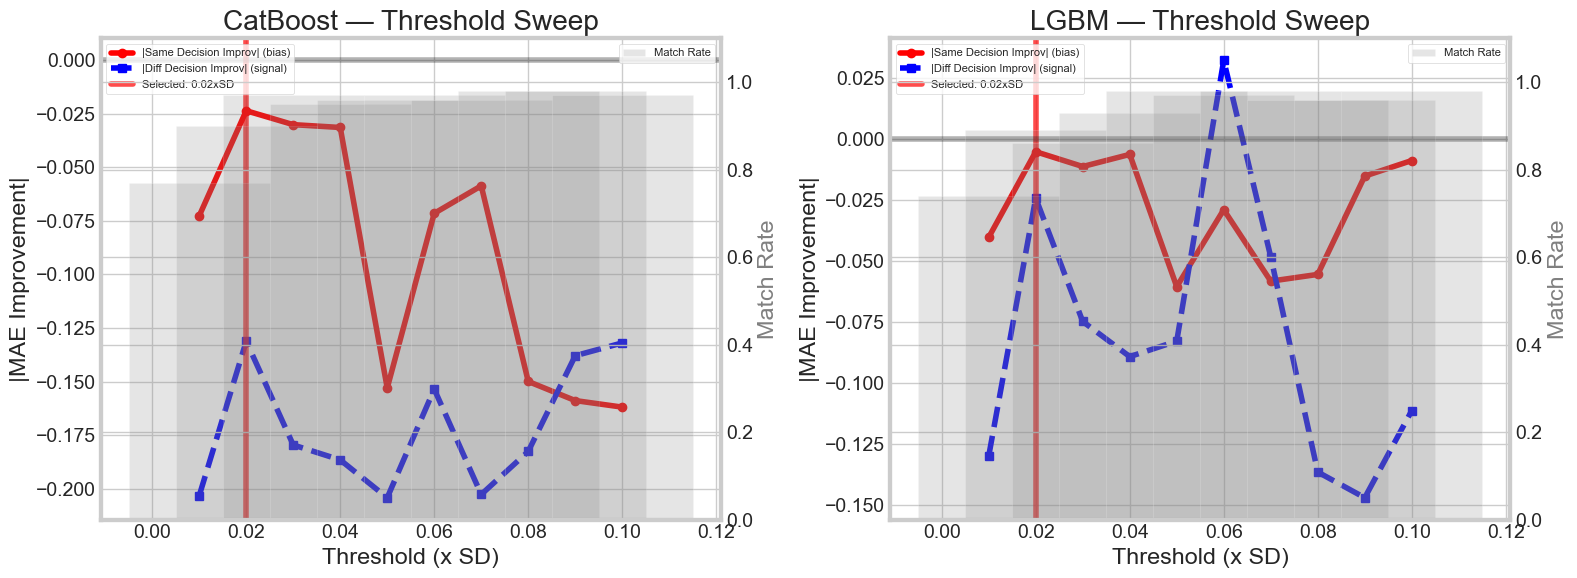


Using thresholds: CatBoost=1,525, LGBM=1,520


In [207]:
# Run threshold sweep for both models
print('=== CatBoost Threshold Sweep ===')
sweep_cat, sd_cat = find_optimal_threshold(
    df_test, 'CatBoost', decision_variables[0],
    pred_col='SalePrice_CatBoost_CovOnly',
    sd_range=(0.01, 0.1), n_steps=10, n_iter=100
)

print('\n=== LGBM Threshold Sweep ===')
sweep_lgbm, sd_lgbm = find_optimal_threshold(
    df_test, 'LGBM', decision_variables[0],
    pred_col='SalePrice_LGBM_CovOnly',
    sd_range=(0.01, 0.1), n_steps=10, n_iter=100
)

# Select optimal thresholds
best_cat = select_threshold(sweep_cat)
best_lgbm = select_threshold(sweep_lgbm)

print(f'\n{"=" * 60}')
print(f'CatBoost: SD={sd_cat:,.0f}, Austin 0.2xSD={0.2*sd_cat:,.0f}')
print(f'  Selected: {best_cat["sd_multiplier"]:.2f}xSD = {best_cat["threshold"]:,.0f}')
print(f'  Match rate: {best_cat["match_rate"]:.2%}, '
      f'Same Decision Improvement: {best_cat["same_decision_improvement"]:.4f}')

print(f'\nLGBM: SD={sd_lgbm:,.0f}, Austin 0.2xSD={0.2*sd_lgbm:,.0f}')
print(f'  Selected: {best_lgbm["sd_multiplier"]:.2f}xSD = {best_lgbm["threshold"]:,.0f}')
print(f'  Match rate: {best_lgbm["match_rate"]:.2%}, '
      f'Same Decision Improvement: {best_lgbm["same_decision_improvement"]:.4f}')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, sweep, sd, model_name, best in [
    (axes[0], sweep_cat, sd_cat, 'CatBoost', best_cat),
    (axes[1], sweep_lgbm, sd_lgbm, 'LGBM', best_lgbm),
]:
    valid = sweep.dropna(subset=['same_decision_improvement'])

    # Bar chart for match rate (secondary axis)
    ax2 = ax.twinx()
    ax2.bar(valid['sd_multiplier'], valid['match_rate'],
            width=0.03, alpha=0.2, color='gray', label='Match Rate')
    ax2.set_ylabel('Match Rate', color='gray')
    ax2.set_ylim(0, 1.1)

    # Line charts for improvements
    ax.plot(valid['sd_multiplier'], valid['same_decision_improvement'],
            'o-', color='red', label='|Same Decision Improv| (bias)')
    ax.plot(valid['sd_multiplier'], valid['diff_decision_improvement'],
            's--', color='blue', label='|Diff Decision Improv| (signal)')

    # Reference lines
    # ax.axvline(0.2, color='green', linestyle='--', alpha=0.7, label='Austin 0.2xSD')
    ax.axvline(best['sd_multiplier'], color='red', linestyle='-',
               alpha=0.7, label=f'Selected: {best["sd_multiplier"]:.2f}xSD')
    ax.axhline(0, color='black', linestyle='-', alpha=0.3)

    ax.set_xlabel('Threshold (x SD)')
    ax.set_ylabel('|MAE Improvement|')
    ax.set_title(f'{model_name} — Threshold Sweep')
    ax.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# Store optimal thresholds for use in matching
optimal_threshold_cat = best_cat['threshold']
optimal_threshold_lgbm = best_lgbm['threshold']
print(f'\nUsing thresholds: CatBoost={optimal_threshold_cat:,.0f}, LGBM={optimal_threshold_lgbm:,.0f}')

In [209]:
# Matching with data-driven thresholds
N = 100
optimal_threshold_combined = np.min([best_cat['threshold'], best_lgbm['threshold']])

dict_result_cat = make_dict()
dict_result_lgbm = make_dict()

# Iteration
for i in tqdm(range(N)):

  # Matching
  dict_result_cat_append = matching(df_test, 'CatBoost', decision_variables[0], optimal_threshold_combined)
  for keys in list(dict_result_cat_append.keys()) :
    dict_result_cat[keys].append(dict_result_cat_append[keys])

  dict_result_lgbm_append = matching(df_test, 'LGBM', decision_variables[0], optimal_threshold_combined)
  for keys in list(dict_result_lgbm_append.keys()) :
    dict_result_lgbm[keys].append(dict_result_lgbm_append[keys])


100%|██████████| 100/100 [00:00<00:00, 603.63it/s]


In [210]:
## Result improvement
def evaluate(dict_result):

    # prepare data
    t = pd.DataFrame(dict_result)
    t['mae_cov_only'] = (
        abs(t['main_predicted_cov_only'] - t['main_actual'])
        + abs(t['matching_predicted_cov_only'] - t['matching_actual'])
    ) / 2
    t['mae_full'] = (
        abs(t['main_predicted_full'] - t['main_actual'])
        + abs(t['matching_predicted_full'] - t['matching_actual'])
    ) / 2
    t['decision_tag'] = t['main_decision'] == t['matching_decision']

    for subset_name, mask in [
        ('Overall', slice(None)),
        ('Same Decision', t['decision_tag']),
        ('Diff Decision', ~t['decision_tag']),
    ]:
        data = t if isinstance(mask, slice) else t[mask]
        if len(data) == 0:
            print(f'{subset_name}: No data')
            continue
        cov_mean = data['mae_cov_only'].mean()
        full_mean = data['mae_full'].mean()
        improv = (full_mean - cov_mean) / cov_mean if cov_mean != 0 else np.nan

        # Bootstrap CI
        boot_improv = []
        for _ in range(1000):
            b = data.sample(n=len(data), replace=True)
            bc = b['mae_cov_only'].mean()
            bf = b['mae_full'].mean()
            boot_improv.append((bf - bc) / bc if bc != 0 else np.nan)
        ci_lo, ci_hi = np.nanpercentile(boot_improv, [2.5, 97.5])
        ci_includes_zero = ci_lo <= 0 <= ci_hi
        zero_tag = 'includes 0' if ci_includes_zero else 'excludes 0'

        print(f'{subset_name} MAE: Cov={cov_mean:.4f}, Full={full_mean:.4f}, '
              f'Improvement={improv:.4f} '
              f'(95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]) [{zero_tag}]')


print('Model : CatBoost')
evaluate(dict_result_cat)

print('=' * 100)
print('\nModel : LGBM')
evaluate(dict_result_lgbm)

Model : CatBoost
Overall MAE: Cov=17769.5847, Full=15332.3437, Improvement=-0.1372 (95% CI: [-0.2019, -0.0666]) [excludes 0]
Same Decision MAE: Cov=15475.4017, Full=15045.1449, Improvement=-0.0278 (95% CI: [-0.0860, 0.0518]) [includes 0]
Diff Decision MAE: Cov=19208.3097, Full=15512.4514, Improvement=-0.1924 (95% CI: [-0.2753, -0.1059]) [excludes 0]

Model : LGBM
Overall MAE: Cov=17748.0256, Full=15736.7582, Improvement=-0.1133 (95% CI: [-0.1845, -0.0387]) [excludes 0]
Same Decision MAE: Cov=18754.8143, Full=17016.3665, Improvement=-0.0927 (95% CI: [-0.1830, -0.0087]) [excludes 0]
Diff Decision MAE: Cov=17165.1480, Full=14995.9323, Improvement=-0.1264 (95% CI: [-0.2247, -0.0140]) [excludes 0]


In [212]:
# Summary interpretation
def summarize_effect(dict_result, model_name):
    t = pd.DataFrame(dict_result)
    t['mae_cov'] = (
        abs(t['main_predicted_cov_only'] - t['main_actual'])
        + abs(t['matching_predicted_cov_only'] - t['matching_actual'])
    ) / 2
    t['mae_full'] = (
        abs(t['main_predicted_full'] - t['main_actual'])
        + abs(t['matching_predicted_full'] - t['matching_actual'])
    ) / 2
    t['decision_tag'] = t['main_decision'] == t['matching_decision']

    same = t[t['decision_tag']]
    diff = t[~t['decision_tag']]

    def bootstrap_ci(data, cov_col='mae_cov', full_col='mae_full', n_boot=1000):
        boots = []
        for _ in range(n_boot):
            b = data.sample(n=len(data), replace=True)
            bc, bf = b[cov_col].mean(), b[full_col].mean()
            boots.append((bf - bc) / bc if bc != 0 else np.nan)
        return np.nanpercentile(boots, [2.5, 97.5])

    same_improv = (same['mae_full'].mean() - same['mae_cov'].mean()) / same['mae_cov'].mean() if len(same) > 0 else np.nan
    diff_improv = (diff['mae_full'].mean() - diff['mae_cov'].mean()) / diff['mae_cov'].mean() if len(diff) > 0 else np.nan

    same_ci = bootstrap_ci(same) if len(same) > 10 else (np.nan, np.nan)
    diff_ci = bootstrap_ci(diff) if len(diff) > 10 else (np.nan, np.nan)

    same_zero = same_ci[0] <= 0 <= same_ci[1]
    diff_zero = diff_ci[0] <= 0 <= diff_ci[1]

    print(f'Decision Variable Effect Analysis ({model_name}):')
    print('=' * 55)
    print('Bias check (Same Decision MAE Improvement):')
    print(f'  Point estimate: {same_improv:.4f} | 95% CI: [{same_ci[0]:.4f}, {same_ci[1]:.4f}]')
    print(f'  Includes zero: {"Yes" if same_zero else "No"}')
    bias_ok = same_zero
    print()
    print('Causal signal (Diff Decision MAE Improvement):')
    print(f'  Point estimate: {diff_improv:.4f} | 95% CI: [{diff_ci[0]:.4f}, {diff_ci[1]:.4f}]')
    print(f'  Includes zero: {"Yes" if diff_zero else "No"}')
    signal_ok = not diff_zero and diff_improv < 0
    print()

    if bias_ok and signal_ok:
        print('Conclusion: Low bias + significant causal signal.')
        print('The decision variable likely has a real effect on the outcome.')
    elif bias_ok and not signal_ok:
        print('Conclusion: Low bias but no significant causal signal detected.')
        print('The decision variable may not meaningfully affect the outcome.')
    elif not bias_ok and signal_ok:
        print('Conclusion: Causal signal detected but potential confounding bias.')
        print('Tighten the matching threshold or add more covariates.')
    else:
        print('Conclusion: No clear evidence of causal effect.')
    print()


summarize_effect(dict_result_cat, 'CatBoost')
print()
summarize_effect(dict_result_lgbm, 'LGBM')

Decision Variable Effect Analysis (CatBoost):
Bias check (Same Decision MAE Improvement):
  Point estimate: -0.0278 | 95% CI: [-0.0872, 0.0515]
  Includes zero: Yes

Causal signal (Diff Decision MAE Improvement):
  Point estimate: -0.1924 | 95% CI: [-0.2805, -0.0994]
  Includes zero: No

Conclusion: Low bias + significant causal signal.
The decision variable likely has a real effect on the outcome.


Decision Variable Effect Analysis (LGBM):
Bias check (Same Decision MAE Improvement):
  Point estimate: -0.0927 | 95% CI: [-0.1831, -0.0077]
  Includes zero: No

Causal signal (Diff Decision MAE Improvement):
  Point estimate: -0.1264 | 95% CI: [-0.2196, -0.0241]
  Includes zero: No

Conclusion: Causal signal detected but potential confounding bias.
Tighten the matching threshold or add more covariates.



# Classification : Income

In [213]:
# Load data
df = load_dataset("scikit-learn/adult-census-income")['train'].to_pandas()

In [214]:
# Overview
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [215]:
# Change target variable to numerical
df['income_cat'] = (df['income'] == '>50K').astype('int64')

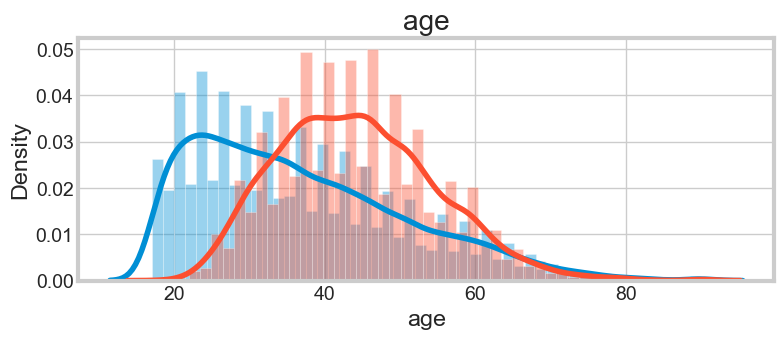

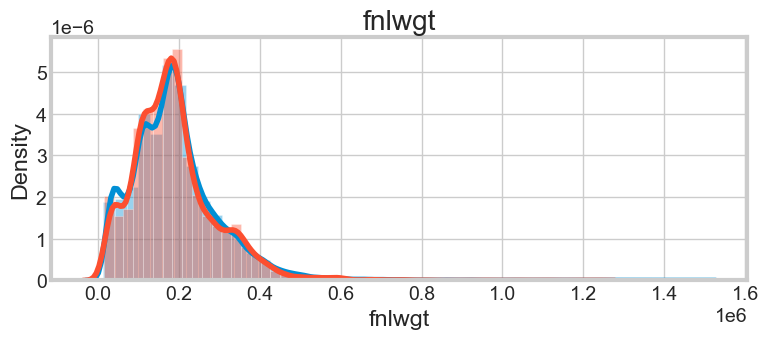

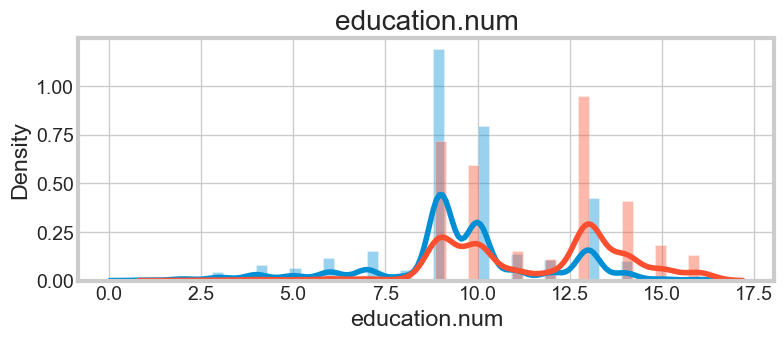

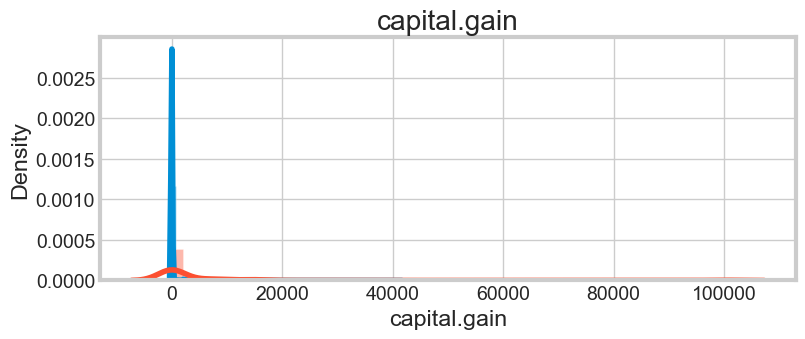

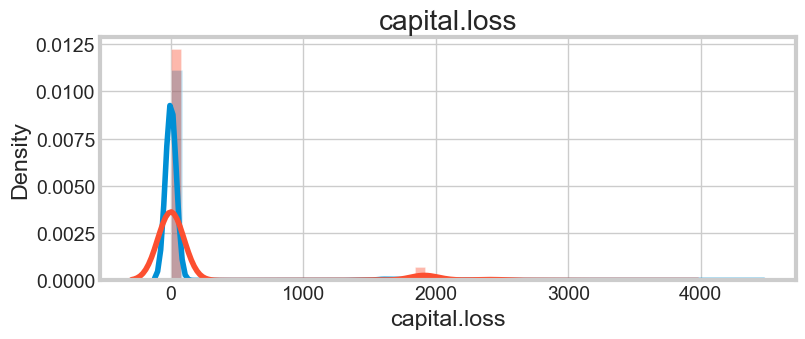

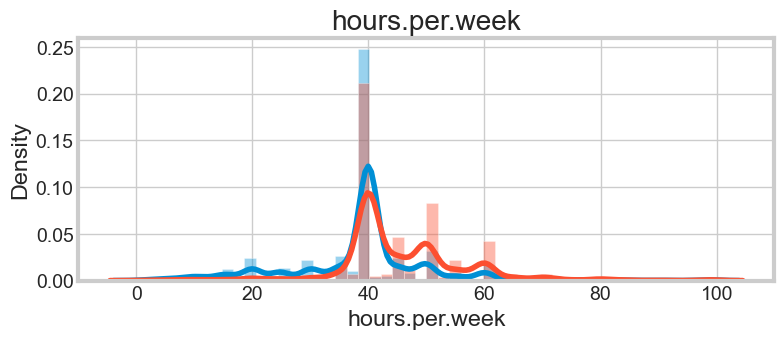

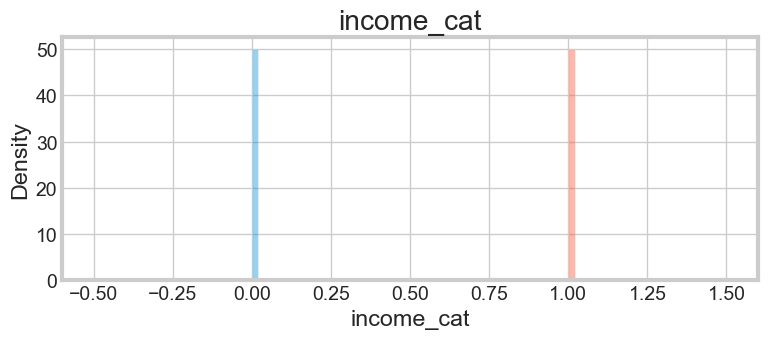

In [216]:
rcParams['figure.figsize'] = [8,3]
plt.style.use('fivethirtyeight')
sns.set_style('whitegrid')

# Distribution of numerical variable
for col in df.columns :
  if df[col].dtype != 'object' :
    sns.distplot(df[df['income']=='<=50K'][col], label='<=50K')
    sns.distplot(df[df['income']=='>50K'][col], label='>50K')
    plt.title(col)
    plt.show()

In [217]:
# Correlation
dict_result = {
    'col' : [],
    'correlation' : [],
    'abs_correlation' : [],
    'tag' : []
}

target = 'income_cat'

for col in df.columns :
  if df[col].dtype != 'object' and col != target :
    corr = df[[col, target]].corr().loc[col, target]

    if abs(corr) < 0.2 :
      tag = 'Low'
    elif abs(corr) < 0.6 :
      tag = 'Medium'
    else :
      tag = 'High'

    dict_result['col'].append(col)
    dict_result['correlation'].append(corr)
    dict_result['abs_correlation'].append(abs(corr))
    dict_result['tag'].append(tag)

pd.DataFrame(dict_result).sort_values(by='abs_correlation', ascending=False)

,col,correlation,abs_correlation,tag
2,education.num,0.3352,0.3352,Medium
0,age,0.2340,0.2340,Medium
5,hours.per.week,0.2297,0.2297,Medium
3,capital.gain,0.2233,0.2233,Medium
4,capital.loss,0.1505,0.1505,Low
1,fnlwgt,-0.0095,0.0095,Low


In [218]:
rcParams['figure.figsize'] = [8,3]
plt.style.use('fivethirtyeight')
sns.set_style('whitegrid')

# Distribution of categorical variable
for col in df.columns :
  if df[col].dtype == 'object' :
    print(f'\n{df[col].value_counts() / len(df)}')


workclass
Private            0.6970
Self-emp-not-inc   0.0780
Local-gov          0.0643
?                  0.0564
State-gov          0.0399
Self-emp-inc       0.0343
Federal-gov        0.0295
Without-pay        0.0004
Never-worked       0.0002
Name: count, dtype: float64

education
HS-grad        0.3225
Some-college   0.2239
Bachelors      0.1645
Masters        0.0529
Assoc-voc      0.0424
11th           0.0361
Assoc-acdm     0.0328
10th           0.0287
7th-8th        0.0198
Prof-school    0.0177
9th            0.0158
12th           0.0133
Doctorate      0.0127
5th-6th        0.0102
1st-4th        0.0052
Preschool      0.0016
Name: count, dtype: float64

marital.status
Married-civ-spouse      0.4599
Never-married           0.3281
Divorced                0.1365
Separated               0.0315
Widowed                 0.0305
Married-spouse-absent   0.0128
Married-AF-spouse       0.0007
Name: count, dtype: float64

occupation
Prof-specialty      0.1271
Craft-repair        0.1259
Exec-mana

In [219]:
# Categorical variable chi square check
import pandas as pd
from scipy.stats import chi2_contingency


def chi_square_test(df, categorical_cols, target_col):
    """
    Perform chi-square test for multiple categorical variables
    """
    results = []

    for col in categorical_cols:
        # Create contingency table
        contingency_table = pd.crosstab(df[col], df[target_col])

        # Perform chi-square test
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)

        # Calculate Cramér's V (effect size)
        n = contingency_table.sum().sum()
        min_dim = min(contingency_table.shape) - 1
        cramers_v = (chi2 / (n * min_dim)) ** 0.5

        # Interpretation
        if cramers_v < 0.1:
            strength = "Negligible"
        elif cramers_v < 0.2:
            strength = "Weak"
        elif cramers_v < 0.4:
            strength = "Moderate"
        else:
            strength = "Strong"

        results.append({
            'variable': col,
            'chi2': chi2,
            'p_value': p_value,
            'dof': dof,
            'cramers_v': cramers_v,
            'strength' : strength,
            'significant': p_value < 0.05
        })

    return pd.DataFrame(results).sort_values('chi2', ascending=False)


# Identify categorical columns
target = 'income'

categorical_cols = []
for col in df.columns :
  if df[col].dtype == 'object' and col != target :
    categorical_cols.append(col)

# Run chi-square tests
results = chi_square_test(df, categorical_cols, target)
results

,variable,chi2,p_value,dof,cramers_v,strength,significant
4,relationship,6699.0769,0.0000,5,0.4536,Strong,True
2,marital.status,6517.7417,0.0000,6,0.4474,Strong,True
1,education,4429.6533,0.0000,15,0.3688,Moderate,True
3,occupation,4031.9743,0.0000,14,0.3519,Moderate,True
6,sex,1517.8134,0.0000,1,0.2159,Moderate,True
0,workclass,1045.7086,0.0000,8,0.1792,Weak,True
5,race,330.9204,0.0000,4,0.1008,Weak,True
7,native.country,317.2304,0.0000,41,0.0987,Negligible,True


In [348]:
## Determine variable
target = 'income_cat'
# decision_variables = ['occupation']
decision_variables = ["education.num"]
covariates = [
    "relationship",
    "marital.status",
    "occupation",
    "sex",
    "age",
    "hours.per.week",
    # "education.num",
    "capital.gain"
]

cat_columns = list(df.columns[~df.apply(is_numeric)])
full_model_cat_features = [c for c in cat_columns if c in covariates + decision_variables]
covariate_model_cat_features = [c for c in cat_columns if c in covariates]


In [349]:
# Change categorical features to category
for col in full_model_cat_features :
  df[col] = df[col].astype('category')

In [350]:
## Building model for causal modelling
if df_test[decision_variables[0]].dtype.name in ('category'):
    monotone_constraints = {}
    monotone_constraints_for_lgbm_full = [monotone_constraints.get(col, 0) if col in covariates else 0 for col in covariates + decision_variables]
else:
    monotone_constraints = {
        decision_variables[0]: 0,
    }
    monotone_constraints_for_lgbm_full = [monotone_constraints.get(col, 0) if col in covariates else 0 for col in covariates + decision_variables]


# Split data
df_train, df_test = train_test_split(df, test_size=.20, random_state=11)

# Building CatBoost
start_time = time.time()
full_model_cat = CatBoostClassifier(
        monotone_constraints=monotone_constraints,
        silent=True
    ).fit(
        X=df_train[covariates + decision_variables],
        y=df_train[target],
        cat_features=full_model_cat_features,
    )

cov_model_cat = CatBoostClassifier(
        silent=True
    ).fit(
        X=df_train[covariates],
        y=df_train[target],
        cat_features=covariate_model_cat_features,
    )

end_time = time.time()
print(f'CatBoost Modelling Finished after {(end_time - start_time) / 60:.4f} minutes')

# Building LightGBM
start_time = time.time()

full_model_lgbm = LGBMClassifier(
    monotone_constraints=monotone_constraints_for_lgbm_full,
    verbose=-1  # silent mode
).fit(
    X=df_train[covariates + decision_variables],
    y=df_train[target],
    categorical_feature=full_model_cat_features
)

cov_model_lgbm = LGBMClassifier(
    verbose=-1  # silent mode
).fit(
    X=df_train[covariates],
    y=df_train[target],
    categorical_feature=covariate_model_cat_features
)

end_time = time.time()
print(f'LightGBM Modelling Finished after {(end_time - start_time) / 60:.4f} minutes')


CatBoost Modelling Finished after 0.1780 minutes
LightGBM Modelling Finished after 0.0153 minutes


In [351]:
# Prediction
df_test[f'{target}_CatBoost_CovOnly'] = cov_model_cat.predict_proba(df_test[cov_model_cat.feature_names_])[:, -1]
df_test[f'{target}_CatBoost_Full'] = full_model_cat.predict_proba(df_test[full_model_cat.feature_names_])[:, -1]
df_test[f'{target}_LGBM_CovOnly'] = cov_model_lgbm.predict_proba(df_test[cov_model_lgbm.feature_name_])[:, -1]
df_test[f'{target}_LGBM_Full'] = full_model_lgbm.predict_proba(df_test[full_model_lgbm.feature_name_])[:, -1]

In [ ]:
# Check the value counts of decision_variables
decision_col = decision_variables[0]
print(f'Number of unique value : {len(df_test[decision_col].unique())}')
try:
    print(f'Min value : {np.min(df_test[decision_col])}')
    print(f'Max value : {np.max(df_test[decision_col])}')
except Exception:
    pass
print('Distribution of the unique value :')
print(df_test[decision_col].value_counts())

In [353]:
# Group decision variable into quantile-based bins (only if high-granularity)
# If the variable is categorical or has few unique values, keep it as-is.
n_decision_groups = 4
decision_col = decision_variables[0]

is_categorical = df_test[decision_col].dtype.name in ('category', 'object')
n_unique = df_test[decision_col].nunique()

if is_categorical or n_unique <= n_decision_groups:
    df_test['decision_group'] = df_test[decision_col]
    print(f'Decision variable "{decision_col}" kept as-is ({n_unique} unique values):')
    print(df_test['decision_group'].value_counts().sort_index())
else:
    df_test['decision_group'] = pd.qcut(
        df_test[decision_col], q=n_decision_groups, labels=False, duplicates='drop'
    )
    print(f'Decision variable "{decision_col}" grouped into {df_test["decision_group"].nunique()} groups:')
    print(df_test.groupby('decision_group')[decision_col].agg(['min', 'max', 'count']))

Decision variable "education.num" grouped into 4 groups:
                min  max  count
decision_group                 
0                 1    9   2895
1                10   10   1517
2                11   13   1525
3                14   16    576


In [354]:
# Make function for matching
def make_dict() :
  dict_result = {
    'main_sample' : [],
    'matching_sample' : [],
    'main_decision' : [],
    'matching_decision' : [],
    'main_actual' : [],
    'matching_actual' : [],
    'main_predicted_cov_only' : [],
    'matching_predicted_cov_only' : [],
    'main_predicted_full' : [],
    'matching_predicted_full' : [],
  }

  return dict_result


def matching(df_test, model, decisions, threshold) :

  # Get main sample
  dict_result = {}
  df_sample = df_test.sample(n=1)
  df_sample_idx = df_sample.index
  df_test_copy = df_test.copy().drop(df_sample_idx)
  main_pred_cov = df_sample[f'{target}_{model}_CovOnly'].values[0]

  # Get matching sample with main sample, and random sample 1
  df_test_copy['is_matched'] = df_test_copy[f'{target}_{model}_CovOnly'].between(main_pred_cov - threshold, main_pred_cov + threshold)

  # Append to result
  if sum(df_test_copy['is_matched']) > 0 :
    df_matching_sample = df_test_copy[df_test_copy['is_matched']].sample(n=1)

    dict_result['main_sample'] = df_sample.index
    dict_result['matching_sample'] = df_matching_sample.index
    dict_result['main_decision'] = df_sample[decisions].values[0]
    dict_result['matching_decision'] = df_matching_sample[decisions].values[0]
    dict_result['main_actual'] = df_sample[f'{target}'].values[0]
    dict_result['matching_actual'] = df_matching_sample[f'{target}'].values[0]
    dict_result['main_predicted_cov_only'] = df_sample[f'{target}_{model}_CovOnly'].values[0]
    dict_result['matching_predicted_cov_only'] = df_matching_sample[f'{target}_{model}_CovOnly'].values[0]
    dict_result['main_predicted_full'] = df_sample[f'{target}_{model}_Full'].values[0]
    dict_result['matching_predicted_full'] = df_matching_sample[f'{target}_{model}_Full'].values[0]

  return dict_result

## Data-Driven Threshold Selection (Austin's Caliper Rule) — Classification

Same approach as regression, but using **log-loss** instead of MAE as the evaluation metric.
The bias diagnostic is: Same Decision Log-loss Improvement should be near zero.

## Prognostic Score Quality Check (Classification)

Compare the quality of CatBoost vs LGBM covariate-only probability predictions.
Noisier prognostic scores lead to worse matching and apparent confounding bias.

In [ ]:
# Prognostic Score Quality Comparison (Classification)
from sklearn.metrics import brier_score_loss, roc_auc_score

print('=== Prognostic Score Quality (Covariate-Only Models) ===')
print()

# 1. Prediction accuracy: Brier score, AUC, MAE of cov-only predictions
for model_name, pred_col in [('CatBoost', f'{target}_CatBoost_CovOnly'),
                              ('LGBM', f'{target}_LGBM_CovOnly')]:
    mae = abs(df_test[pred_col] - df_test[target]).mean()
    brier = brier_score_loss(df_test[target], df_test[pred_col])
    auc = roc_auc_score(df_test[target], df_test[pred_col])
    std = df_test[pred_col].std()
    print(f'{model_name} Cov-Only: MAE={mae:.4f}, Brier={brier:.4f}, AUC={auc:.4f}, Score SD={std:.4f}')

print()

# 2. Correlation between the two prognostic scores
corr = df_test[f'{target}_CatBoost_CovOnly'].corr(df_test[f'{target}_LGBM_CovOnly'])
print(f'Correlation between CatBoost & LGBM prognostic scores: {corr:.4f}')
print()

# 3. Residual correlation with decision variable
try:
    for model_name, pred_col in [('CatBoost', f'{target}_CatBoost_CovOnly'),
                                ('LGBM', f'{target}_LGBM_CovOnly')]:
        residual = df_test[target] - df_test[pred_col]
        corr_with_decision = residual.corr(df_test[decision_variables[0]])
        print(f'{model_name} residual correlation with {decision_variables[0]}: {corr_with_decision:.4f}')

    print()
    print('Interpretation:')
    print('  - Lower Brier / higher AUC / lower MAE = better prognostic score')
    print('  - If residual-decision correlations differ significantly between models,')
    print('    the model with LOWER correlation may be leaking decision info into')
    print('    its prognostic score, causing confounding bias in the matching diagnostic.')
except Exception:
    pass

In [356]:
def find_optimal_threshold_clf(df_test, model, decisions, pred_col,
                               sd_range=(0.05, 0.50), n_steps=10,
                               n_iter=500):
    """
    Sweep thresholds for classification using MAE on probability scale.
    Consistent with the regression threshold sweep approach.
    """
    scores = df_test[pred_col]
    sd = scores.std()
    multipliers = np.linspace(sd_range[0], sd_range[1], n_steps)
    thresholds = multipliers * sd

    results = []
    for mult, thresh in zip(multipliers, thresholds):
        dict_result = make_dict()
        n_matched = 0
        for _ in range(n_iter):
            res = matching(df_test, model, decisions, thresh)
            if res:
                n_matched += 1
                for k in res:
                    dict_result[k].append(res[k])

        match_rate = n_matched / n_iter
        row = {'sd_multiplier': round(mult, 3), 'threshold': round(thresh, 4),
               'match_rate': match_rate, 'n_matches': n_matched}

        if n_matched >= 10:
            t = pd.DataFrame(dict_result)
            t['mae_cov'] = (
                abs(t['main_predicted_cov_only'] - t['main_actual'])
                + abs(t['matching_predicted_cov_only'] - t['matching_actual'])
            ) / 2
            t['mae_full'] = (
                abs(t['main_predicted_full'] - t['main_actual'])
                + abs(t['matching_predicted_full'] - t['matching_actual'])
            ) / 2
            t['decision_tag'] = t['main_decision'] == t['matching_decision']

            overall_improv = (t['mae_full'].mean() - t['mae_cov'].mean()) / t['mae_cov'].mean()
            same = t[t['decision_tag']]
            diff = t[~t['decision_tag']]
            same_improv = (
                (same['mae_full'].mean() - same['mae_cov'].mean()) / same['mae_cov'].mean()
                if len(same) > 0 else np.nan
            )
            diff_improv = (
                (diff['mae_full'].mean() - diff['mae_cov'].mean()) / diff['mae_cov'].mean()
                if len(diff) > 0 else np.nan
            )

            row.update({
                'overall_improvement': overall_improv,
                'same_decision_improvement': same_improv,
                'diff_decision_improvement': diff_improv,
            })
        else:
            row.update({
                'overall_improvement': np.nan,
                'same_decision_improvement': np.nan,
                'diff_decision_improvement': np.nan,
            })

        results.append(row)
        print(f'  {mult:.2f}xSD (threshold={thresh:.4f}): match_rate={match_rate:.2f}, '
              f'same_decision_improv={row.get("same_decision_improvement", float("nan")):.4f}')

    return pd.DataFrame(results), sd

In [357]:
len(df_test)

6513

=== CatBoost Threshold Sweep (Classification) ===
  0.01xSD (threshold=0.0029): match_rate=1.00, same_decision_improv=-0.0931
  0.02xSD (threshold=0.0058): match_rate=1.00, same_decision_improv=-0.0850
  0.03xSD (threshold=0.0088): match_rate=1.00, same_decision_improv=-0.0930
  0.04xSD (threshold=0.0117): match_rate=1.00, same_decision_improv=-0.0733
  0.05xSD (threshold=0.0146): match_rate=1.00, same_decision_improv=-0.0810
  0.06xSD (threshold=0.0175): match_rate=1.00, same_decision_improv=-0.0968
  0.07xSD (threshold=0.0204): match_rate=1.00, same_decision_improv=-0.0870
  0.08xSD (threshold=0.0233): match_rate=1.00, same_decision_improv=-0.0693
  0.09xSD (threshold=0.0263): match_rate=1.00, same_decision_improv=-0.1092
  0.10xSD (threshold=0.0292): match_rate=1.00, same_decision_improv=-0.0557

=== LGBM Threshold Sweep (Classification) ===
  0.01xSD (threshold=0.0029): match_rate=1.00, same_decision_improv=-0.0992
  0.02xSD (threshold=0.0059): match_rate=1.00, same_decision_improv

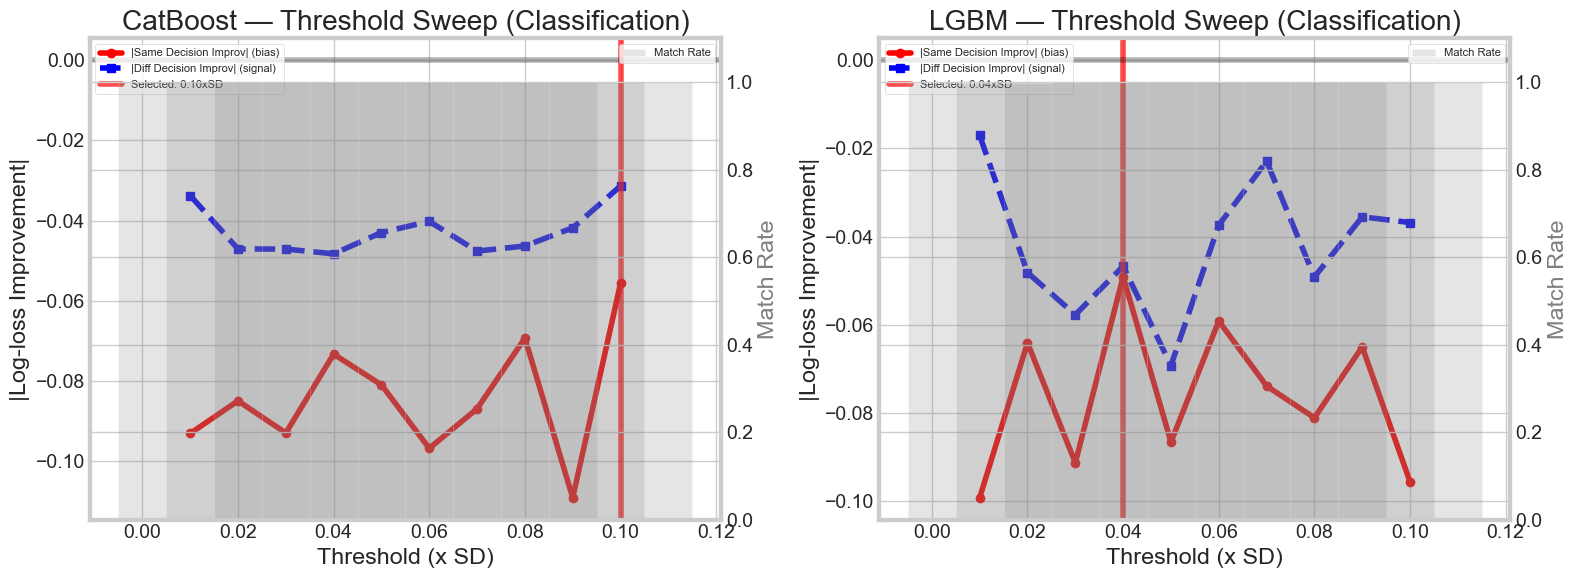


Using thresholds: CatBoost=0.0292, LGBM=0.0118


In [358]:
# Run threshold sweep for both models (Classification)
print('=== CatBoost Threshold Sweep (Classification) ===')
sweep_cat, sd_cat = find_optimal_threshold_clf(
    df_test, 'CatBoost', 'decision_group',
    pred_col=f'{target}_CatBoost_CovOnly',
    sd_range=(0.01, 0.10), n_steps=10, n_iter=1000
)

print('\n=== LGBM Threshold Sweep (Classification) ===')
sweep_lgbm, sd_lgbm = find_optimal_threshold_clf(
    df_test, 'LGBM', 'decision_group',
    pred_col=f'{target}_LGBM_CovOnly',
    sd_range=(0.01, 0.10), n_steps=10, n_iter=1000
)

# Select optimal thresholds
best_cat = select_threshold(sweep_cat)
best_lgbm = select_threshold(sweep_lgbm)

print(f'\n{"=" * 60}')
print(f'CatBoost: SD={sd_cat:.4f}, Austin 0.2xSD={0.2*sd_cat:.4f}')
print(f'  Selected: {best_cat["sd_multiplier"]:.2f}xSD = {best_cat["threshold"]:.4f}')
print(f'  Match rate: {best_cat["match_rate"]:.2%}, '
      f'Same Decision Improvement: {best_cat["same_decision_improvement"]:.4f}')

print(f'\nLGBM: SD={sd_lgbm:.4f}, Austin 0.2xSD={0.2*sd_lgbm:.4f}')
print(f'  Selected: {best_lgbm["sd_multiplier"]:.2f}xSD = {best_lgbm["threshold"]:.4f}')
print(f'  Match rate: {best_lgbm["match_rate"]:.2%}, '
      f'Same Decision Improvement: {best_lgbm["same_decision_improvement"]:.4f}')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, sweep, sd, model_name, best in [
    (axes[0], sweep_cat, sd_cat, 'CatBoost', best_cat),
    (axes[1], sweep_lgbm, sd_lgbm, 'LGBM', best_lgbm),
]:
    valid = sweep.dropna(subset=['same_decision_improvement'])

    # Bar chart for match rate (secondary axis)
    ax2 = ax.twinx()
    ax2.bar(valid['sd_multiplier'], valid['match_rate'],
            width=0.03, alpha=0.2, color='gray', label='Match Rate')
    ax2.set_ylabel('Match Rate', color='gray')
    ax2.set_ylim(0, 1.1)

    # Line charts for improvements
    ax.plot(valid['sd_multiplier'], valid['same_decision_improvement'],
            'o-', color='red', label='|Same Decision Improv| (bias)')
    ax.plot(valid['sd_multiplier'], valid['diff_decision_improvement'],
            's--', color='blue', label='|Diff Decision Improv| (signal)')

    # Reference lines
    # ax.axvline(0.2, color='green', linestyle='--', alpha=0.7, label='Austin 0.2xSD')
    ax.axvline(best['sd_multiplier'], color='red', linestyle='-',
               alpha=0.7, label=f'Selected: {best["sd_multiplier"]:.2f}xSD')
    ax.axhline(0, color='black', linestyle='-', alpha=0.3)

    ax.set_xlabel('Threshold (x SD)')
    ax.set_ylabel('|Log-loss Improvement|')
    ax.set_title(f'{model_name} — Threshold Sweep (Classification)')
    ax.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# Store optimal thresholds for use in matching
optimal_threshold_cat = best_cat['threshold']
optimal_threshold_lgbm = best_lgbm['threshold']
print(f'\nUsing thresholds: CatBoost={optimal_threshold_cat:.4f}, LGBM={optimal_threshold_lgbm:.4f}')


In [359]:
# Matching with data-driven thresholds
N = 1000
optimal_threshold_combined = np.min([optimal_threshold_cat, optimal_threshold_lgbm])

dict_result_cat = make_dict()
dict_result_lgbm = make_dict()

# Iteration
for i in tqdm(range(N)):

  # Matching
  dict_result_cat_append = matching(df_test, 'CatBoost', 'decision_group', optimal_threshold_combined)
  for keys in list(dict_result_cat_append.keys()) :
    dict_result_cat[keys].append(dict_result_cat_append[keys])

  dict_result_lgbm_append = matching(df_test, 'LGBM', 'decision_group', optimal_threshold_combined)
  for keys in list(dict_result_lgbm_append.keys()) :
    dict_result_lgbm[keys].append(dict_result_lgbm_append[keys])


100%|██████████| 1000/1000 [00:02<00:00, 388.68it/s]


In [360]:
## Result improvement
def evaluate(dict_result):
    t = pd.DataFrame(dict_result)

    # Metric 1: MAE on probability scale (direct analogue of regression MAE)
    t['mae_cov'] = (
        abs(t['main_predicted_cov_only'] - t['main_actual'])
        + abs(t['matching_predicted_cov_only'] - t['matching_actual'])
    ) / 2
    t['mae_full'] = (
        abs(t['main_predicted_full'] - t['main_actual'])
        + abs(t['matching_predicted_full'] - t['matching_actual'])
    ) / 2

    # Metric 2: Brier score — (pred - actual)^2, proper scoring rule, bounded [0,1]
    t['brier_cov'] = (
        (t['main_predicted_cov_only'] - t['main_actual']) ** 2
        + (t['matching_predicted_cov_only'] - t['matching_actual']) ** 2
    ) / 2
    t['brier_full'] = (
        (t['main_predicted_full'] - t['main_actual']) ** 2
        + (t['matching_predicted_full'] - t['matching_actual']) ** 2
    ) / 2

    # Metric 3: Risk difference — |pred_full - pred_cov| per sample, in probability units
    t['risk_diff'] = (
        abs(t['main_predicted_full'] - t['main_predicted_cov_only'])
        + abs(t['matching_predicted_full'] - t['matching_predicted_cov_only'])
    ) / 2

    t['decision_tag'] = t['main_decision'] == t['matching_decision']

    # Print MAE and Brier with overall / same / diff breakdown + bootstrap CIs
    for metric_name, cov_col, full_col in [
        ('MAE (Probability)', 'mae_cov', 'mae_full'),
        ('Brier Score', 'brier_cov', 'brier_full'),
    ]:
        print(f'--- {metric_name} ---')
        for subset_name, mask in [
            ('Overall', slice(None)),
            ('Same Decision', t['decision_tag']),
            ('Diff Decision', ~t['decision_tag']),
        ]:
            data = t if isinstance(mask, slice) else t[mask]
            if len(data) == 0:
                print(f'  {subset_name}: No data')
                continue
            cov_mean = data[cov_col].mean()
            full_mean = data[full_col].mean()
            improv = (full_mean - cov_mean) / cov_mean if cov_mean != 0 else np.nan

            # Bootstrap CI
            boot_improv = []
            for _ in range(1000):
                b = data.sample(n=len(data), replace=True)
                bc = b[cov_col].mean()
                bf = b[full_col].mean()
                boot_improv.append((bf - bc) / bc if bc != 0 else np.nan)
            ci_lo, ci_hi = np.nanpercentile(boot_improv, [2.5, 97.5])
            ci_includes_zero = ci_lo <= 0 <= ci_hi
            zero_tag = 'includes 0' if ci_includes_zero else 'excludes 0'

            print(f'  {subset_name}: Cov={cov_mean:.4f}, Full={full_mean:.4f}, '
                  f'Improvement={improv:.4f} '
                  f'(95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]) [{zero_tag}]')
        print()

    # Risk difference: same vs diff decision
    print('--- Risk Difference (Prediction Shift) ---')
    same_rd = t[t['decision_tag']]['risk_diff'].mean()
    diff_rd = t[~t['decision_tag']]['risk_diff'].mean()
    print(f'  Same Decision:  {same_rd:.4f} ({same_rd * 100:.2f} percentage points)')
    print(f'  Diff Decision:  {diff_rd:.4f} ({diff_rd * 100:.2f} percentage points)')


print('Model : CatBoost')
evaluate(dict_result_cat)

print('=' * 100)
print('\nModel : LGBM')
evaluate(dict_result_lgbm)

Model : CatBoost
--- MAE (Probability) ---
  Overall: Cov=0.1972, Full=0.1870, Improvement=-0.0517 (95% CI: [-0.0714, -0.0321]) [excludes 0]
  Same Decision: Cov=0.1655, Full=0.1503, Improvement=-0.0914 (95% CI: [-0.1253, -0.0594]) [excludes 0]
  Diff Decision: Cov=0.2149, Full=0.2074, Improvement=-0.0346 (95% CI: [-0.0565, -0.0114]) [excludes 0]

--- Brier Score ---
  Overall: Cov=0.0967, Full=0.0934, Improvement=-0.0335 (95% CI: [-0.0674, 0.0001]) [includes 0]
  Same Decision: Cov=0.0766, Full=0.0729, Improvement=-0.0488 (95% CI: [-0.1026, 0.0085]) [includes 0]
  Diff Decision: Cov=0.1078, Full=0.1049, Improvement=-0.0274 (95% CI: [-0.0698, 0.0164]) [includes 0]

--- Risk Difference (Prediction Shift) ---
  Same Decision:  0.0396 (3.96 percentage points)
  Diff Decision:  0.0543 (5.43 percentage points)

Model : LGBM
--- MAE (Probability) ---
  Overall: Cov=0.2072, Full=0.1962, Improvement=-0.0532 (95% CI: [-0.0707, -0.0366]) [excludes 0]
  Same Decision: Cov=0.2118, Full=0.1927, Imp

In [ ]:
# Summary interpretation (Classification)
def summarize_effect_clf(dict_result, model_name):
    t = pd.DataFrame(dict_result)
    t['mae_cov'] = (
        abs(t['main_predicted_cov_only'] - t['main_actual'])
        + abs(t['matching_predicted_cov_only'] - t['matching_actual'])
    ) / 2
    t['mae_full'] = (
        abs(t['main_predicted_full'] - t['main_actual'])
        + abs(t['matching_predicted_full'] - t['matching_actual'])
    ) / 2
    t['risk_diff'] = (
        abs(t['main_predicted_full'] - t['main_predicted_cov_only'])
        + abs(t['matching_predicted_full'] - t['matching_predicted_cov_only'])
    ) / 2
    t['decision_tag'] = t['main_decision'] == t['matching_decision']

    same = t[t['decision_tag']]
    diff = t[~t['decision_tag']]

    def bootstrap_ci(data, cov_col='mae_cov', full_col='mae_full', n_boot=1000):
        boots = []
        for _ in range(n_boot):
            b = data.sample(n=len(data), replace=True)
            bc, bf = b[cov_col].mean(), b[full_col].mean()
            boots.append((bf - bc) / bc if bc != 0 else np.nan)
        return np.nanpercentile(boots, [2.5, 97.5])

    same_improv = (same['mae_full'].mean() - same['mae_cov'].mean()) / same['mae_cov'].mean() if len(same) > 0 else np.nan
    diff_improv = (diff['mae_full'].mean() - diff['mae_cov'].mean()) / diff['mae_cov'].mean() if len(diff) > 0 else np.nan

    same_ci = bootstrap_ci(same) if len(same) > 10 else (np.nan, np.nan)
    diff_ci = bootstrap_ci(diff) if len(diff) > 10 else (np.nan, np.nan)

    same_zero = same_ci[0] <= 0 <= same_ci[1]
    diff_zero = diff_ci[0] <= 0 <= diff_ci[1]

    same_rd = same['risk_diff'].mean() if len(same) > 0 else np.nan
    diff_rd = diff['risk_diff'].mean() if len(diff) > 0 else np.nan

    print(f'Decision Variable Effect Analysis ({model_name}):')
    print('=' * 55)
    print('Bias check (Same Decision MAE Improvement):')
    print(f'  Point estimate: {same_improv:.4f} | 95% CI: [{same_ci[0]:.4f}, {same_ci[1]:.4f}]')
    print(f'  Includes zero: {"Yes" if same_zero else "No"}')
    bias_ok = same_zero
    print()
    print('Causal signal (Diff Decision MAE Improvement):')
    print(f'  Point estimate: {diff_improv:.4f} | 95% CI: [{diff_ci[0]:.4f}, {diff_ci[1]:.4f}]')
    print(f'  Includes zero: {"Yes" if diff_zero else "No"}')
    signal_ok = not diff_zero and diff_improv < 0
    print()
    print('Practical significance (Risk Difference):')
    print(f'  Same Decision:  {same_rd:.4f} ({same_rd * 100:.2f} percentage points)')
    print(f'  Diff Decision:  {diff_rd:.4f} ({diff_rd * 100:.2f} percentage points)')
    print()

    if bias_ok and signal_ok:
        print('Conclusion: Low bias + significant causal signal.')
        print('The decision variable likely has a real effect on the outcome.')
    elif bias_ok and not signal_ok:
        print('Conclusion: Low bias but no significant causal signal detected.')
        print('The decision variable may not meaningfully affect the outcome.')
    elif not bias_ok and signal_ok:
        print('Conclusion: Causal signal detected but potential confounding bias.')
        print('Tighten the matching threshold or add more covariates.')
    else:
        print('Conclusion: No clear evidence of causal effect.')
    print()


summarize_effect_clf(dict_result_cat, 'CatBoost')
print()
summarize_effect_clf(dict_result_lgbm, 'LGBM')